# SOP: harmonizing two cohorts with the BioMapper Python package
## Worked case: UK Biobank × Arivale (metabolites, proteins, clinical labs)

**Purpose.** This notebook is a standard operating procedure (SOP) for harmonizing two cohorts'
measurement panels with the `biomapper` package. Follow it top to bottom to harmonize any two
cohorts; UK Biobank (UKBB) × Arivale is the worked example, and every number it produces is
checked against the Activity 2 milestone report.

**What harmonizing means here.** Two cohorts rarely name a measurement the same way. We
(1) **map** each measurement to a standard identifier, an entry in the KRAKEN knowledge graph
(a graph that integrates the major biomedical identifier systems and the cross-references between
them); then (2) **match** measurements across the two cohorts when they share an entry or another
identifier; then (3) **verify** what can be verified: a chemical-structure check for metabolites,
accession agreement for proteins, and manual review for clinical labs.

**Two ways, reported separately.** Each cohort pair is matched two ways and reported separately
rather than combined: once using measurement names alone, and once adding the identifiers a
cohort publishes (for example, LOINC codes for lab tests).

**Prerequisites.** biomapper 1.5.5 (see Part 0). No API key is needed: the hosted BioMapper API is
keyless. Only panel metadata is used (measurement names and published identifiers, shipped in
`notebooks/data/ukbb_arivale/`); no participant data is read.

**Replay by default.** Mapping the 5,593 measurements (twice, once per approach) live takes hours on the shared deployment
(roughly 4.4 seconds per measurement). By default this notebook **replays** the exact mapping results
the milestone runs saved, so it runs in minutes with no API load. Set `RUN_LIVE = True` in the next
cell to call the hosted API instead.

## Part 0: Install and select the kernel

Run from the repository root.

```bash
uv venv .venv --python 3.11
uv pip install --python .venv/bin/python 'biomapper==1.5.5' ipykernel nbconvert matplotlib

# Optional: register the environment under the kernel name this notebook declares.
.venv/bin/python -m ipykernel install --user \
    --name biomapper-1-5-5 --display-name "Python 3.11 (biomapper 1.5.5)"

# Execute headless (from the repository root):
.venv/bin/jupyter nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.kernel_name=biomapper-1-5-5 notebooks/ukbb_arivale_harmonization_sop.ipynb
```

The notebook declares a kernel named `biomapper-1-5-5`, but does not depend on it existing: any
Python 3.11 kernel with `biomapper==1.5.5` installed works (plain `pip install "biomapper==1.5.5"`
is enough). The first code cell checks the installed version and stops if it is not 1.5.5, because
name matching for metabolites (`link_by_name`) first shipped in 1.5.5.

In [1]:
import collections, datetime, gzip, hashlib, json, re, time, urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import biomapper
from biomapper.harmonize import harmonize
from biomapper.models import MappingResult

RUN_LIVE = False   # True = call the hosted BioMapper API for every measurement (slow; see above)

assert biomapper.__version__ == "1.5.5", f"this SOP is pinned to biomapper 1.5.5, found {biomapper.__version__}"

# Resolve everything relative to the repository, so the notebook runs from any checkout.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
DATA = NOTEBOOK_DIR / "data" / "ukbb_arivale"
PANELS, REPLAY, MILESTONE_LINKS = DATA / "panels", DATA / "replay", DATA / "milestone_links"
assert DATA.is_dir(), "run from the repository root or from notebooks/"
STAMP = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUTPUT_DIR = NOTEBOOK_DIR / "outputs" / STAMP          # git-ignored
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", 70)
print("biomapper", biomapper.__version__, "| live API calls:", RUN_LIVE,
      "| outputs -> notebooks/outputs/" + STAMP)

biomapper 1.5.5 | live API calls: False | outputs -> notebooks/outputs/20261002T193730Z


### Step 0: Pin the versions
Every result depends on the software release and on the knowledge-graph build. Read both live and
record them. Offline, replay mode falls back to the pin shipped with the data; live mode needs the
endpoints. The milestone results were produced on KRAKEN `kg_version` 2.3.0, package 2.2.0, build
commit 3dd08a5b; if the live graph differs, replayed results still reproduce the milestone, but a
live re-run would not be like for like.

In [2]:
def get_json(url):
    with urllib.request.urlopen(url, timeout=60) as r:
        return json.load(r)

PIN = json.loads((DATA / "MANIFEST.json").read_text())["pin"]   # the build the shipped results came from
# Each check is handled on its own, so a live KRAKEN result is never replaced by the shipped pin.
try:
    kg = get_json("https://kestrel.krakenkg.com/api/health")["kg_build"]
    pin_source = "live /health"
except Exception as exc:  # offline: replay still works from the shipped results
    if RUN_LIVE:
        raise
    print(f"KRAKEN /health unreachable ({type(exc).__name__}); replaying with the shipped pin")
    kg = {"kg_version": PIN["kg_version"], "kraken_package_version": PIN["kraken_package_version"],
          "git_commit": PIN["kraken_git_commit"], "build_timestamp": ""}
    pin_source = "shipped MANIFEST.json (KRAKEN /health unreachable)"
try:
    api = get_json("https://biomapper.expertintheloop.io/api/v1/health")
except Exception as exc:
    if RUN_LIVE:
        raise
    print(f"BioMapper API /health unreachable ({type(exc).__name__}); not needed for replay")
    api = {"status": f"not checked ({type(exc).__name__})"}
pins = pd.Series({
    "biomapper package (this kernel)": biomapper.__version__,
    "KRAKEN kg_version": kg["kg_version"],
    "KRAKEN kraken_package_version": kg.get("kraken_package_version"),
    "KRAKEN build git_commit": kg.get("git_commit", "")[:8],
    "KRAKEN build timestamp": kg.get("build_timestamp", "")[:19],
    "BioMapper API /health status": api.get("status"),
    "versions read from": pin_source,
}, name="value")
MILESTONE_PIN = ("2.3.0", "2.2.0", "3dd08a5b")
SAME_BUILD = (kg["kg_version"], kg.get("kraken_package_version"), kg.get("git_commit", "")[:8]) == MILESTONE_PIN
if RUN_LIVE:
    assert SAME_BUILD, "live graph differs from the milestone pin; a live run would not be comparable"
print(f"graph build ({pin_source}) matches the milestone pin:", SAME_BUILD)
pins.to_frame()

graph build (live /health) matches the milestone pin: True


,value
biomapper package (this kernel),1.5.5
KRAKEN kg_version,2.3.0
KRAKEN kraken_package_version,2.2.0
KRAKEN build git_commit,3dd08a5b
KRAKEN build timestamp,2026-09-25T00:34:42
BioMapper API /health status,healthy
versions read from,live /health


### Step 1: Inputs
Each cohort supplies one panel file per measurement type. Verify each shipped file's SHA-256 checksum
against the data manifest (the panels' checksums equal those recorded by the runs that produced the
milestone figures), so a changed file cannot slip through.

In [3]:
def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

data_manifest = json.loads((DATA / "MANIFEST.json").read_text())
for rel, digest in data_manifest["sha256"].items():
    assert sha256(DATA / rel) == digest, f"checksum mismatch: {rel}"
replay_manifest = json.loads((REPLAY / "replay_manifest.json").read_text())
FILES = {}
rows = []
for ent, info in replay_manifest.items():
    for side in ("ukbb", "arivale"):
        p = PANELS / info["inputs"][side]["file"]
        assert sha256(p) == info["inputs"][side]["sha256"], f"checksum mismatch: {p.name}"
        FILES[(ent, side)] = p
        rows.append({"measurement type": ent, "cohort": "UK Biobank" if side == "ukbb" else "Arivale",
                     "file": p.name, "sha256 (first 12)": info["inputs"][side]["sha256"][:12],
                     "checksum": "matches the milestone run"})
print(f"all {len(data_manifest['sha256'])} shipped data files match MANIFEST.json")
pd.DataFrame(rows)

all 16 shipped data files match MANIFEST.json


,measurement type,cohort,file,sha256 (first 12),checksum
0,metabolites,UK Biobank,metabolites_ukbb_ukbb_nmr_meta.tsv,931612656f6d,matches the milestone run
1,metabolites,Arivale,metabolites_arivale_metabolomics_metadata.tsv,a086b6fdf595,matches the milestone run
2,proteins,UK Biobank,proteins_ukbb_ukbb_protein_meta.tsv,3a19ddcbb4e7,matches the milestone run
3,proteins,Arivale,proteins_arivale_proteomics_metadata.tsv,92dae79d144a,matches the milestone run
4,labs,UK Biobank,labs_ukbb_ukbb_chemistry_full_20250924.tsv,1451b3f20bfb,matches the milestone run
5,labs,Arivale,labs_arivale_chemistries_metadata.tsv,e04c2d50cad9,matches the milestone run


### Step 2: Inclusion rules
Not every row in a panel file is a measurement. Each exclusion is applied by an explicit rule and
counted, so nothing is dropped silently. A **record** is one measurement to map: a key, the name
to search, and any identifiers the cohort publishes for it.

- **Arivale metabolites:** drop blank names and unnamed vendor features of the form "X - 12345"
  (they carry no chemical identity, yet a search would still return an entry for them).
- **UK Biobank clinical labs:** the field list is a range of field numbers, not a list of analytes.
  Drop bare "Field NNNNN" placeholders, quality-control / timing / administrative fields, non-numeric
  fields and two numeric fields that are not lab analytes. Rows whose data type is "Unknown" but
  which name a lab analyte are **admitted** (38 rows added to the fuller field list without
  descriptive metadata).

In [4]:
def blank(v):
    return v is None or (isinstance(v, float) and v != v) or str(v).strip() in ("", "nan", "NaN")

def clean_id(v):
    if blank(v):
        return None
    s = str(v).strip()
    return s[:-2] if s.endswith(".0") and s[:-2].isdigit() else (s or None)

def split_accessions(cell):
    # UK Biobank writes multi-protein assays as "P29459_P29460", Arivale as "P29460,P29459".
    if blank(cell):
        return []
    parts = [cell]
    for sep in (",", "_", ";", "|"):
        parts = [q for p in parts for q in str(p).split(sep)]
    return [p.strip() for p in parts if p.strip()]

def read_arivale(path):
    skip = 0
    with open(path) as fh:
        for line in fh:
            if line.startswith("#"):
                skip += 1
            else:
                break
    return pd.read_csv(path, sep="\t", skiprows=skip, dtype=str)

QC = re.compile(r"(freeze-thaw cycles|acquisition time|acquisition route|device ID|missing reason"
                r"|reportability|result flag|correction level|correction reason|aliquot|assay date"
                r"|plate barcode|well position|sign-off timestamp|\(interim dataset\)|date sent)", re.I)
PLACEHOLDER = re.compile(r"^Field\s+\d+$", re.I)
NOT_A_LAB_ANALYTE = {"Rate of ramp phase load increase (exercise test)",
                     "V02max per kg bodyweight estimated from the exercise test"}

def load(ent, side):
    """Apply the inclusion rule for one panel. Returns (records, exclusion counts, admitted rows)."""
    recs, drops, admitted, seen = [], collections.Counter(), [], set()
    def add(key, name, ids):
        if key in seen:
            drops["duplicate key"] += 1
            return
        seen.add(key)
        recs.append({"key": key, "name": name, "identifiers": ids})
    if (ent, side) == ("metabolites", "ukbb"):
        for _, r in pd.read_csv(FILES[(ent, side)], sep="\t", dtype=str).dropna(how="all").iterrows():
            add(f"{r['field_id']}|{str(r['title']).strip()}", str(r["title"]).strip(), {})
    elif (ent, side) == ("metabolites", "arivale"):
        for _, r in read_arivale(FILES[(ent, side)]).iterrows():
            name = r["BIOCHEMICAL_NAME"]
            if blank(name):
                drops["blank name"] += 1; continue
            name = str(name).strip()
            if name.startswith("X - ") and name[4:].strip().isdigit():
                drops["unnamed vendor feature (X - 12345)"] += 1; continue
            ids = {}
            for col, vocab in (("KEGG", "KEGG"), ("HMDB", "HMDB"), ("PUBCHEM", "PUBCHEM.COMPOUND"), ("CAS", "CAS")):
                v = clean_id(r.get(col))
                if v:
                    ids[vocab] = [p.strip() for p in v.split(";") if p.strip()]
            add(f"{r['CHEMICAL_ID']}|{name}", name, ids)
    elif (ent, side) == ("proteins", "ukbb"):
        for _, r in pd.read_csv(FILES[(ent, side)], sep="\t", dtype=str).dropna(how="all").iterrows():
            assay, acc = r.get("Assay"), r.get("UniProt")
            if blank(assay):
                drops["blank assay name"] += 1; continue
            add(f"{str(assay).strip()}|{'' if blank(acc) else str(acc).strip()}", str(assay).strip(),
                {} if blank(acc) else {"UniProtKB": split_accessions(acc)})
    elif (ent, side) == ("proteins", "arivale"):
        for _, r in read_arivale(FILES[(ent, side)]).iterrows():
            gene, acc = r.get("gene_name"), r.get("uniprot")
            if blank(gene):
                drops["blank gene name"] += 1; continue
            add(f"{str(r['name']).strip()}|{str(gene).strip()}", str(gene).strip(),
                {} if blank(acc) else {"UniProtKB": split_accessions(acc)})
    elif (ent, side) == ("labs", "ukbb"):
        for _, r in pd.read_csv(FILES[(ent, side)], sep="\t", dtype=str).dropna(how="all").iterrows():
            name = str(r.get("field_name") or "").strip()
            dtype = str(r.get("data_type") or "").strip()
            if PLACEHOLDER.match(name):
                drops["unnamed placeholder field"] += 1; continue
            if QC.search(name):
                drops["quality-control, timing or administrative field"] += 1; continue
            if dtype == "Unknown":
                admitted.append({"field_id": r["field_id"], "name": name})
            elif dtype != "Continuous":
                drops["non-numeric data type"] += 1; continue
            if name in NOT_A_LAB_ANALYTE:
                drops["numeric field that is not a lab analyte"] += 1; continue
            add(f"{r['field_id']}|{name}", name, {})
    elif (ent, side) == ("labs", "arivale"):
        for _, r in read_arivale(FILES[(ent, side)]).iterrows():
            disp, raw = r.get("Display Name"), r.get("Name")
            name = disp if not blank(disp) else raw
            if blank(name):
                drops["blank name"] += 1; continue
            loincs = []
            for col in ("Labcorp LOINC ID", "Quest LOINC ID"):
                v = clean_id(r.get(col))
                if v and v not in loincs:
                    loincs.append(v)
            add(f"{str(raw).strip()}|{str(name).strip()}", str(name).strip(), {"LOINC": loincs} if loincs else {})
    return recs, drops, admitted

RECORDS, summary = {}, []
for ent in ("metabolites", "proteins", "labs"):
    for side in ("ukbb", "arivale"):
        recs, drops, admitted = load(ent, side)
        RECORDS[(ent, side)] = recs
        summary.append({"measurement type": ent, "cohort": "UK Biobank" if side == "ukbb" else "Arivale",
                        "kept": len(recs), "excluded": sum(drops.values()),
                        "exclusions by reason": "; ".join(f"{k}: {v}" for k, v in drops.items()) or "none"})
        if admitted:
            ADMITTED = pd.DataFrame(admitted)
inclusion = pd.DataFrame(summary)
inclusion

,measurement type,cohort,kept,excluded,exclusions by reason
0,metabolites,UK Biobank,251,0,none
1,metabolites,Arivale,1029,322,blank name: 53; unnamed vendor feature (X - 12345): 269
2,proteins,UK Biobank,2923,0,none
3,proteins,Arivale,1197,0,none
4,labs,UK Biobank,65,276,"quality-control, timing or administrative field: 113; non-numeric ..."
5,labs,Arivale,128,0,none


The 38 UK Biobank lab rows admitted despite an "Unknown" data type: each names a measured analyte
(blood count fields 30160 to 30300; blood biochemistry 30610 to 30690 and 30760 to 30890).

In [5]:
assert len(ADMITTED) == 38
ADMITTED.T

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
field_id,30160,30170,30180,30190,30200,30210,30220,30230,30240,30250,...,30800,30810,30820,30830,30840,30850,30860,30870,30880,30890
name,Basophill count,Nucleated red blood cell count,Lymphocyte percentage,Monocyte percentage,Neutrophill percentage,Eosinophill percentage,Basophill percentage,Nucleated red blood cell percentage,Reticulocyte percentage,Reticulocyte count,...,Oestradiol,Phosphate,Rheumatoid factor,SHBG,Total bilirubin,Testosterone,Total protein,Triglycerides,Urate,Vitamin D


### Step 3: Map each measurement to a standard identifier
BioMapper maps each record to a KRAKEN entry. The **entity type** tells it what kind of thing to
look for: `biolink:SmallMolecule` for metabolites, `biolink:Protein` for proteins and
`biolink:ClinicalFinding` for clinical labs. Each record is mapped twice: names alone, and names plus
the cohort's published identifiers.

The live call is `BioMapperClient.map_entities(records=..., entity_type=...)` in batches of 10
(larger batches slow the shared deployment down sharply). In replay mode the identical results are
read from the milestone runs' saved outputs, looked up by a key built from the entity type, the name
and the identifiers submitted. The lookup failing for any record would mean this notebook's
inclusion rules differ from the milestone runs', so it is asserted.

In [6]:
ENTITY_TYPE = {"metabolites": "biolink:SmallMolecule", "proteins": "biolink:Protein",
               "labs": "biolink:ClinicalFinding"}
APPROACHES = {"names alone": False, "with published identifiers": True}

def lookup_key(entity_type, name, identifiers):
    payload = json.dumps({"t": entity_type, "n": name,
                          "i": {k: sorted(v) for k, v in sorted(identifiers.items())}}, sort_keys=True)
    return hashlib.sha256(payload.encode()).hexdigest()

async def map_live(records, entity_type, use_ids):
    from biomapper.client import BioMapperClient
    out = []
    async with BioMapperClient(anonymous=True, timeout=300) as client:
        for i in range(0, len(records), 10):
            batch = [{"name": r["name"], "identifiers": r["identifiers"] if use_ids else {}} for r in records[i:i + 10]]
            out += await client.map_entities(records=batch, entity_type=entity_type)
    return out

MAPPED = {}
for ent in ENTITY_TYPE:
    with gzip.open(REPLAY / f"{ent}_replay.json.gz", "rt") as fh:
        replay = json.load(fh)
    for approach, use_ids in APPROACHES.items():
        for side in ("ukbb", "arivale"):
            recs = RECORDS[(ent, side)]
            if RUN_LIVE:
                MAPPED[(ent, approach, side)] = await map_live(recs, ENTITY_TYPE[ent], use_ids)
            else:
                keys = [lookup_key(ENTITY_TYPE[ent], r["name"], r["identifiers"] if use_ids else {}) for r in recs]
                missing = [r["key"] for r, k in zip(recs, keys) if k not in replay]
                assert not missing, f"{ent}/{side}: {len(missing)} records not in replay, e.g. {missing[:3]}"
                MAPPED[(ent, approach, side)] = [MappingResult.model_validate(replay[k]) for k in keys]

mapped = pd.DataFrame([{"measurement type": e, "approach": a, "cohort": "UK Biobank" if s == "ukbb" else "Arivale",
                        "measurements": len(res), "mapped to an entry": sum(bool(r.chosen_kg_id) for r in res),
                        "errors": sum(bool(r.error) for r in res)}
                       for (e, a, s), res in MAPPED.items()])
mapped["% mapped"] = (100 * mapped["mapped to an entry"] / mapped["measurements"]).round(1)
mapped

,measurement type,approach,cohort,measurements,mapped to an entry,errors,% mapped
0,metabolites,names alone,UK Biobank,251,246,0,98.0
1,metabolites,names alone,Arivale,1029,1029,0,100.0
2,metabolites,with published identifiers,UK Biobank,251,246,0,98.0
3,metabolites,with published identifiers,Arivale,1029,1024,0,99.5
4,proteins,names alone,UK Biobank,2923,2923,0,100.0
5,proteins,names alone,Arivale,1197,1197,0,100.0
6,proteins,with published identifiers,UK Biobank,2923,2922,0,100.0
7,proteins,with published identifiers,Arivale,1197,1192,0,99.6
8,labs,names alone,UK Biobank,65,65,0,100.0
9,labs,names alone,Arivale,128,126,0,98.4


A peek at what one mapping looks like (metabolite, names alone): the entry chosen, and how many
identifier systems that entry carries cross-references in.

In [7]:
r = MAPPED[("metabolites", "names alone", "arivale")][0]
pd.Series({"name": r.query_name, "entry chosen": r.chosen_kg_id,
           "identifier systems on the entry": len(r.kg_equivalent_ids),
           "structure check": r.certificate.state if r.certificate else None})

name                               S-1-pyrroline-5-carboxylate
entry chosen                                        RM:0118021
identifier systems on the entry                             12
structure check                                   corroborated
dtype: object

### Step 4: Match across the two cohorts
`biomapper.harmonize.harmonize` matches a UK Biobank and an Arivale measurement when their entries
share an identifier (chemical-structure identifiers are excluded, so matching never uses what the
structure check compares). For **metabolites only**, `link_by_name=True` also matches names that are
identical, or identical apart from letter case (not for names of 4 characters or fewer). Every
match records how it was made: shared **node** (the same entry), another shared **identifier**, or
**name**.

**One-to-one matches** are those where the UK Biobank measurement matches exactly one Arivale
measurement and vice versa; they are the conservative count.

In [8]:
MATCHED = {}
for ent in ENTITY_TYPE:
    for approach in APPROACHES:
        a_res, b_res = MAPPED[(ent, approach, "ukbb")], MAPPED[(ent, approach, "arivale")]
        keymap = {id(r): rec["key"] for r, rec in zip(a_res + b_res, RECORDS[(ent, "ukbb")] + RECORDS[(ent, "arivale")])}
        MATCHED[(ent, approach)] = harmonize(a_res, b_res, a_label="ukbb", b_label="arivale",
                                             key=lambda r, _i, _m=keymap: _m[id(r)],
                                             link_by_name=(ent == "metabolites"))

def one_to_one(links):
    cu = collections.Counter(l.a_key for l in links)
    ca = collections.Counter(l.b_key for l in links)
    return [l for l in links if cu[l.a_key] == 1 and ca[l.b_key] == 1]

match_summary = pd.DataFrame([{
    "measurement type": e, "approach": a, "matched pairs": h.n_links, "one-to-one matches": len(one_to_one(h.links)),
    "UK Biobank measurements matched": h.n_a_linked, "Arivale measurements matched": h.n_b_linked,
    **{f"how matched: {k}": v for k, v in h.links_by_basis.items()}} for (e, a), h in MATCHED.items()])
match_summary

,measurement type,approach,matched pairs,one-to-one matches,UK Biobank measurements matched,Arivale measurements matched,how matched: node,how matched: identifier,how matched: name_exact,how matched: name_casefold
0,metabolites,names alone,28,15,24,24,28,0,0,0
1,metabolites,with published identifiers,96,15,92,25,96,0,0,0
2,proteins,names alone,1170,1095,1132,1168,1170,0,0,0
3,proteins,with published identifiers,1170,1106,1136,1170,1170,0,0,0
4,labs,names alone,31,20,26,26,31,0,0,0
5,labs,with published identifiers,2,2,2,2,2,0,0,0


**Reproduction check.** The pairs found here must be exactly the pairs the milestone runs saved.

In [9]:
ARM = {"names alone": "name_only", "with published identifiers": "provided_id"}
check = []
for (ent, approach), h in MATCHED.items():
    saved = pd.read_csv(MILESTONE_LINKS / f"{ent}_{ARM[approach]}_links.csv", dtype=str)
    ours = {(l.a_key, l.b_key) for l in h.links}
    theirs = set(zip(saved["ukbb_key"], saved["arivale_key"]))
    assert ours == theirs, (ent, approach, len(ours ^ theirs))
    check.append({"measurement type": ent, "approach": approach, "pairs": len(ours), "identical to milestone run": True})
pd.DataFrame(check)

,measurement type,approach,pairs,identical to milestone run
0,metabolites,names alone,28,True
1,metabolites,with published identifiers,96,True
2,proteins,names alone,1170,True
3,proteins,with published identifiers,1170,True
4,labs,names alone,31,True
5,labs,with published identifiers,2,True


### Step 5: Verify
What "correct" means differs by measurement type.

**Metabolites: chemical-structure check.** For each metabolite, BioMapper compares the structure
implied by the chosen entry with a structure looked up independently in RefMet (Metabolomics
Workbench) or PubChem: **confirmed**, **contradicted**, or **could not be checked** (no independent
structure, which is the correct outcome for lipids reported as a class). The check first reads the
structure the graph itself records, so it is not fully independent of the graph. A match counts as
verified only when the structures of both measurements, the UK Biobank one and the Arivale one, are
confirmed; otherwise it is included in the match counts but not reported as verified.

In [10]:
def verdict(r):
    s = r.certificate.state if r.certificate else None
    return "confirmed" if s == "corroborated" else "contradicted" if s == "contradicted" else "could not be checked"

V = {}
tally = []
for approach in APPROACHES:
    for side in ("ukbb", "arivale"):
        recs, res = RECORDS[("metabolites", side)], MAPPED[("metabolites", approach, side)]
        V.update({(approach, rec["key"]): verdict(r) for rec, r in zip(recs, res)})
        c = collections.Counter(verdict(r) for r in res)
        indep = sum(1 for r in res if verdict(r) == "confirmed" and r.certificate.independent_of_selection is True)
        tally.append({"approach": approach, "cohort": "UK Biobank" if side == "ukbb" else "Arivale", **c,
                      "confirmed by a source independent of the one that chose the entry": indep})
structure_check = pd.DataFrame(tally).fillna(0)
structure_check

,approach,cohort,could not be checked,confirmed,confirmed by a source independent of the one that chose the entry,contradicted
0,names alone,UK Biobank,231,20,8,0.0
1,names alone,Arivale,543,477,226,9.0
2,with published identifiers,UK Biobank,231,20,8,0.0
3,with published identifiers,Arivale,541,473,448,15.0


In [11]:
rows = []
for approach in APPROACHES:
    for l in one_to_one(MATCHED[("metabolites", approach)].links):
        u, a = V[(approach, l.a_key)], V[(approach, l.b_key)]
        rows.append({"approach": approach, "UK Biobank": l.a_key.split("|", 1)[1], "Arivale": l.b_key.split("|", 1)[1],
                     "UK Biobank structure": u, "Arivale structure": a,
                     "verified (both confirmed)": u == a == "confirmed"})
metab_one_to_one = pd.DataFrame(rows)
metab_one_to_one[metab_one_to_one.approach == "names alone"].drop(columns="approach")

,UK Biobank,Arivale,UK Biobank structure,Arivale structure,verified (both confirmed)
0,Total cholines,choline,could not be checked,confirmed,False
1,Ratio of linoleic acid to total fatty acids,linoleate (18:2n6),could not be checked,could not be checked,False
2,Glycine,glycine,confirmed,confirmed,True
3,Histidine,histidine,confirmed,confirmed,True
4,Leucine,leucine,confirmed,confirmed,True
5,Valine,valine,confirmed,confirmed,True
6,Phenylalanine,phenylalanine,confirmed,confirmed,True
7,Tyrosine,tyrosine,confirmed,confirmed,True
8,Glucose,glucose,confirmed,confirmed,True
9,Lactate,lactate,confirmed,confirmed,True


**Proteins: UniProt accession agreement.** Both panels publish UniProt accessions, so a protein
match can be checked against them: does the matched pair share an accession? The reference is the
plain accession match between the two panels.

In [12]:
acc = {side: {rec["key"]: set(rec["identifiers"].get("UniProtKB", [])) for rec in RECORDS[("proteins", side)]}
       for side in ("ukbb", "arivale")}
reference = {(u, a) for u, ua in acc["ukbb"].items() for a, aa in acc["arivale"].items() if ua & aa}
shared_accessions = set().union(*acc["ukbb"].values()) & set().union(*acc["arivale"].values())
prot_rows = []
for approach in APPROACHES:
    pairs = {(l.a_key, l.b_key) for l in MATCHED[("proteins", approach)].links}
    prot_rows.append({"approach": approach, "matched pairs": len(pairs),
                      "pairs sharing a UniProt accession": sum(acc["ukbb"][u] & acc["arivale"][a] != set() for u, a in pairs),
                      "reference pairs recovered": len(pairs & reference), "reference pairs": len(reference)})
protein_check = pd.DataFrame(prot_rows)
print("shared accessions between the two panels:", len(shared_accessions))
protein_check

shared accessions between the two panels: 1139


,approach,matched pairs,pairs sharing a UniProt accession,reference pairs recovered,reference pairs
0,names alone,1170,1162,1162,1172
1,with published identifiers,1170,1170,1170,1172


**Clinical labs: manual review.** Lab tests have no chemical structure to check, so every pair matched
by name was reviewed by hand (the milestone review). The review record below lists the six wrong
pairs and why; every other pair was judged correct.

In [13]:
LAB_REVIEW_WRONG = {
    ("30020", "MCHC"): "graph merges haemoglobin, MCH and MCHC into one entry",
    ("30020", "MCH"): "graph merges haemoglobin, MCH and MCHC into one entry",
    ("30050", "MCHC"): "graph merges haemoglobin, MCH and MCHC into one entry",
    ("30060", "MCH"): "graph merges haemoglobin, MCH and MCHC into one entry",
    ("30510", "CREATININE ENZ, SER"): "graph merges serum and urine creatinine: urine matched to serum",
    ("30090", "PLATELET COUNT THOUSAND"): "separate error: platelet crit (a volume fraction) matched to a platelet count",
}
lab_rows = []
for l in MATCHED[("labs", "names alone")].links:
    k = (l.a_key.split("|")[0], l.b_key.split("|")[0])
    lab_rows.append({"UK Biobank": l.a_key.split("|", 1)[1], "Arivale": l.b_key.split("|", 1)[1],
                     "one-to-one": l in one_to_one(MATCHED[("labs", "names alone")].links),
                     "correct on review": k not in LAB_REVIEW_WRONG, "reason if wrong": LAB_REVIEW_WRONG.get(k, "")})
lab_review = pd.DataFrame(lab_rows)
assert set(LAB_REVIEW_WRONG) <= {(l.a_key.split("|")[0], l.b_key.split("|")[0]) for l in MATCHED[("labs", "names alone")].links}
print(f"correct on review: {lab_review['correct on review'].sum()} of {len(lab_review)}; "
      f"one-to-one correct: {(lab_review['one-to-one'] & lab_review['correct on review']).sum()} of {lab_review['one-to-one'].sum()}")
lab_review[~lab_review["correct on review"]]

correct on review: 25 of 31; one-to-one correct: 19 of 20


,UK Biobank,Arivale,one-to-one,correct on review,reason if wrong
1,Haemoglobin concentration,Mean Corpuscular Hemoglobin Concentration,False,False,"graph merges haemoglobin, MCH and MCHC into one entry"
2,Haemoglobin concentration,Mean Corpuscular Hemoglobin,False,False,"graph merges haemoglobin, MCH and MCHC into one entry"
4,Mean corpuscular haemoglobin,Mean Corpuscular Hemoglobin Concentration,False,False,"graph merges haemoglobin, MCH and MCHC into one entry"
7,Mean corpuscular haemoglobin concentration,Mean Corpuscular Hemoglobin,False,False,"graph merges haemoglobin, MCH and MCHC into one entry"
10,Platelet crit,Platelets,True,False,separate error: platelet crit (a volume fraction) matched to a pla...
17,Creatinine (enzymatic) in urine,Creatinine,False,False,graph merges serum and urine creatinine: urine matched to serum


### Step 6: Results, asserted against the milestone report
Percentages of distinct measurements matched are given two ways: the percent of the measurements
that could be mapped, and the percent of the full panel. Every number below is asserted equal to
the milestone report.

In [14]:
def pct(n, d):
    return f"{100 * n / d:.1f}%"

res_rows = []
for (ent, approach), h in MATCHED.items():
    u_map = sum(bool(r.chosen_kg_id) for r in MAPPED[(ent, approach, "ukbb")])
    a_map = sum(bool(r.chosen_kg_id) for r in MAPPED[(ent, approach, "arivale")])
    nu, na = len(RECORDS[(ent, "ukbb")]), len(RECORDS[(ent, "arivale")])
    row = {"measurement type": ent, "approach": approach, "matched pairs": h.n_links,
           "one-to-one matches": len(one_to_one(h.links)),
           "UK Biobank matched (% of mapped / % of panel)": f"{h.n_a_linked} ({pct(h.n_a_linked, u_map)} / {pct(h.n_a_linked, nu)})",
           "Arivale matched (% of mapped / % of panel)": f"{h.n_b_linked} ({pct(h.n_b_linked, a_map)} / {pct(h.n_b_linked, na)})"}
    if ent == "metabolites":
        row["verified"] = int(metab_one_to_one[metab_one_to_one.approach == approach]["verified (both confirmed)"].sum())
    if ent == "labs" and approach == "names alone":
        row["verified"] = f"{int(lab_review['correct on review'].sum())} correct on review"
    res_rows.append(row)
results = pd.DataFrame(res_rows).fillna("")

R = {(r["measurement type"], r["approach"]): r for r in res_rows}
N, I = "names alone", "with published identifiers"
assert (R[("proteins", N)]["matched pairs"], R[("proteins", N)]["one-to-one matches"]) == (1170, 1095)
assert (R[("proteins", I)]["matched pairs"], R[("proteins", I)]["one-to-one matches"]) == (1170, 1106)
assert R[("proteins", N)]["Arivale matched (% of mapped / % of panel)"] == "1168 (97.6% / 97.6%)"
assert R[("proteins", I)]["Arivale matched (% of mapped / % of panel)"] == "1170 (98.2% / 97.7%)"
assert (R[("metabolites", N)]["matched pairs"], R[("metabolites", I)]["matched pairs"]) == (28, 96)
assert R[("metabolites", N)]["one-to-one matches"] == R[("metabolites", I)]["one-to-one matches"] == 15
assert R[("metabolites", N)]["verified"] == R[("metabolites", I)]["verified"] == 12
assert (R[("labs", N)]["matched pairs"], R[("labs", N)]["one-to-one matches"]) == (31, 20)
assert R[("labs", N)]["verified"] == "25 correct on review"
assert (R[("labs", I)]["matched pairs"], R[("labs", I)]["one-to-one matches"]) == (2, 2)
assert R[("labs", N)]["Arivale matched (% of mapped / % of panel)"] == "26 (20.6% / 20.3%)"
sc = structure_check.set_index(["approach", "cohort"])
assert tuple(sc.loc[(N, "Arivale"), ["confirmed", "contradicted", "could not be checked"]]) == (477, 9, 543)
assert tuple(sc.loc[(I, "Arivale"), ["confirmed", "contradicted", "could not be checked"]]) == (473, 15, 541)
assert tuple(protein_check.set_index("approach").loc[N, ["pairs sharing a UniProt accession", "reference pairs recovered"]]) == (1162, 1162)
assert tuple(protein_check.set_index("approach").loc[I, ["pairs sharing a UniProt accession", "reference pairs recovered", "reference pairs"]]) == (1170, 1170, 1172)
assert len(shared_accessions) == 1139
print("every number matches the milestone report")
results

every number matches the milestone report


,measurement type,approach,matched pairs,one-to-one matches,UK Biobank matched (% of mapped / % of panel),Arivale matched (% of mapped / % of panel),verified
0,metabolites,names alone,28,15,24 (9.8% / 9.6%),24 (2.3% / 2.3%),12
1,metabolites,with published identifiers,96,15,92 (37.4% / 36.7%),25 (2.4% / 2.4%),12
2,proteins,names alone,1170,1095,1132 (38.7% / 38.7%),1168 (97.6% / 97.6%),
3,proteins,with published identifiers,1170,1106,1136 (38.9% / 38.9%),1170 (98.2% / 97.7%),
4,labs,names alone,31,20,26 (40.0% / 40.0%),26 (20.6% / 20.3%),25 correct on review
5,labs,with published identifiers,2,2,2 (3.1% / 3.1%),2 (1.7% / 1.6%),


### Figure 1: matches by name alone, per measurement type

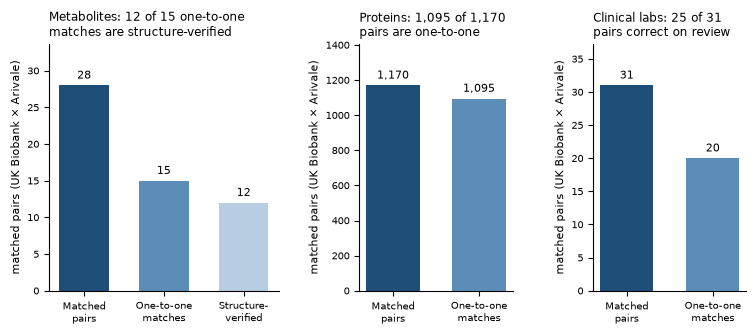

In [15]:
def style(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(direction="out", labelsize=7)

NAVY, MID, LIGHT, GREY = "#1f4e79", "#5b8db8", "#b7cde2", "#8c8c8c"
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2), gridspec_kw={"width_ratios": [3, 2, 2], "wspace": 0.45})
panels = [("metabolites", "Metabolites: 12 of 15 one-to-one\nmatches are structure-verified",
           [("Matched\npairs", R[("metabolites", N)]["matched pairs"], NAVY),
            ("One-to-one\nmatches", R[("metabolites", N)]["one-to-one matches"], MID),
            ("Structure-\nverified", R[("metabolites", N)]["verified"], LIGHT)]),
          ("proteins", "Proteins: 1,095 of 1,170\npairs are one-to-one",
           [("Matched\npairs", R[("proteins", N)]["matched pairs"], NAVY),
            ("One-to-one\nmatches", R[("proteins", N)]["one-to-one matches"], MID)]),
          ("labs", "Clinical labs: 25 of 31\npairs correct on review",
           [("Matched\npairs", R[("labs", N)]["matched pairs"], NAVY),
            ("One-to-one\nmatches", R[("labs", N)]["one-to-one matches"], MID)])]
for ax, (_, title, bars) in zip(axes, panels):
    top = max(b[1] for b in bars)
    ax.bar(range(len(bars)), [b[1] for b in bars], color=[b[2] for b in bars], width=0.62)
    for x, (_, v, _) in enumerate(bars):
        ax.text(x, v + top * 0.02, f"{v:,}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(bars))); ax.set_xticklabels([b[0] for b in bars], fontsize=7)
    ax.set_ylim(0, top * 1.2); ax.set_ylabel("matched pairs (UK Biobank × Arivale)", fontsize=8)
    ax.set_title(title, loc="left", fontsize=8.5); style(ax)
fig.savefig(OUTPUT_DIR / "fig_matches_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

### Figure 2: when only one cohort publishes identifiers, adding them reduces matches
Arivale publishes LOINC codes for its lab tests; UK Biobank publishes none. Supplying Arivale's codes
moves Arivale onto LOINC-specific entries that UK Biobank, matched by name, never reaches.

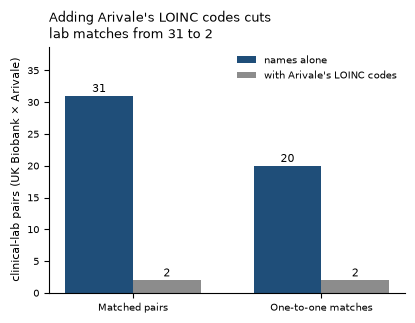

In [16]:
fig, ax = plt.subplots(figsize=(4.6, 3.2))
labels = ["Matched pairs", "One-to-one matches"]
vals_n = [R[("labs", N)]["matched pairs"], R[("labs", N)]["one-to-one matches"]]
vals_i = [R[("labs", I)]["matched pairs"], R[("labs", I)]["one-to-one matches"]]
x = np.arange(2); w = 0.36
ax.bar(x - w / 2, vals_n, w, color=NAVY, label="names alone")
ax.bar(x + w / 2, vals_i, w, color=GREY, label="with Arivale's LOINC codes")
for xi, v in zip(x - w / 2, vals_n):
    ax.text(xi, v + 0.6, str(v), ha="center", fontsize=8)
for xi, v in zip(x + w / 2, vals_i):
    ax.text(xi, v + 0.6, str(v), ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, max(vals_n) * 1.25); ax.set_ylabel("clinical-lab pairs (UK Biobank × Arivale)", fontsize=8)
ax.set_title("Adding Arivale's LOINC codes cuts\nlab matches from 31 to 2", loc="left", fontsize=9)
ax.legend(frameon=False, fontsize=7); style(ax)
fig.savefig(OUTPUT_DIR / "fig_labs_identifier_collapse.png", dpi=300, bbox_inches="tight")
plt.show()

### Step 7: Known limitations
**One measurement can match many.** The pair count is not a count of shared measurements. With
Arivale's identifiers, one Arivale measurement, cholesterol, matches a whole family of UK Biobank
lipoprotein fields:

In [17]:
links_i = MATCHED[("metabolites", I)].links
chol = [l for l in links_i if l.b_key.split("|", 1)[1].lower() == "cholesterol"]
print(f"pairs involving Arivale cholesterol: {len(chol)} of {len(links_i)}")
assert (len(chol), len(links_i)) == (68, 96)
pd.Series([l.a_key.split("|", 1)[1] for l in chol][:8], name="UK Biobank fields matched to Arivale cholesterol (first 8)")

pairs involving Arivale cholesterol: 68 of 96


0                                      Total cholesterol
1                          Total cholesterol minus HDL-C
2    Remnant cholesterol (non-HDL, non-LDL -cholesterol)
3                                       VLDL cholesterol
4                               Clinical LDL cholesterol
5                                        LDL cholesterol
6                                        HDL cholesterol
7                           Total esterified cholesterol
Name: UK Biobank fields matched to Arivale cholesterol (first 8), dtype: object

**Lipoprotein-subclass fields map to the parent molecule.** UK Biobank's NMR panel reports, for
example, "Cholesterol in large LDL". Because metabolites are searched among small-molecule entries
only, these fields land on the plain molecule entry (cholesterol), shared by every cholesterol field.
The knowledge graph does hold subclass-specific measures, but outside the small-molecule category
(for example EFO:0022167 "total cholesterol in large LDL", a phenotypic-feature entry; looked up
2026-10-02), so they cannot be chosen.

In [18]:
ukbb_metab = pd.DataFrame([{"field": rec["name"], "entry": r.chosen_kg_id}
                           for rec, r in zip(RECORDS[("metabolites", "ukbb")], MAPPED[("metabolites", I, "ukbb")])])
top_entries = ukbb_metab["entry"].value_counts().head(5).rename("UK Biobank fields on this entry")
assert top_entries.iloc[0] == 68 and top_entries.index[0] == "RM:0135639"
top_entries.to_frame()

,UK Biobank fields on this entry
entry,
RM:0135639,68
CHEBI:15255,33
HMDB:HMDB0245589,24
HMDB:HMDB0302468,15
CHEBI:61735,10


**Many UK Biobank lab fields map to a related but wrong test.** A lab name maps to a test entry that
is often more specific than the field: a ratio, a threshold finding, another specimen, or a
presence code. A pair can still be correct when both cohorts land on the same wrong entry (glucose
matches glucose on "Glucose 1.5H post dose glucagon"), so the 25 of 31 review holds, but "mapped" says
nothing about whether the entry is the right test. The review below (entry names looked up in the
knowledge graph on 2026-10-02) flags 26 UK Biobank lab fields as a wrong test, plus 2 borderline.

In [19]:
LAB_ENTRY_REVIEW = {  # UK Biobank field id: (entry name in KRAKEN, problem)
    "30000": ("Other cells/Leukocytes in Blood by Manual count", "wrong test"),
    "30020": ("Corpuscular Hemoglobin Concentration Mean", "wrong analyte (MCHC)"),
    "30030": ("Hematocrit Less than 45 Percent", "threshold finding"),
    "30050": ("Corpuscular Hemoglobin Concentration Mean", "wrong analyte (MCHC)"),
    "30080": ("Platelet Count Greater than or Equal to 20000 per Cubic Millimeter", "threshold finding"),
    "30090": ("Platelets [Morphology] in Blood", "wrong analyte"),
    "30120": ("Lymphocytes/cells in Lymph node by Manual count", "wrong specimen"),
    "30140": ("Absolute Neutrophil Count Greater than or Equal to 1000/mm3", "threshold finding"),
    "30160": ("Basophils [#] in Body fluid by Manual count", "wrong specimen"),
    "30180": ("body fluid lymphocytes percentage", "wrong specimen"),
    "30300": ("Reticulocytes.low light scatter", "wrong analyte"),
    "30510": ("Creatinine [Interpretation] in Urine", "interpretation, not a measurement"),
    "30620": ("Aspartate aminotransferase/Alanine aminotransferase [Enzymatic activity ratio]", "ratio"),
    "30630": ("Apolipoprotein E [Presence] in Serum or Plasma", "wrong analyte, presence code"),
    "30640": ("Apolipoprotein B/Apolipoprotein A-I [Percentile]", "ratio"),
    "30660": ("Bilirubin.direct [Mass/volume] in Body fluid", "wrong specimen"),
    "30700": ("Creatinine [Interpretation] in Urine", "wrong specimen"),
    "30720": ("Cystatin C [Measurement] in Urine", "wrong specimen"),
    "30730": ("Gamma glutamyl transferase/Aspartate aminotransferase [Enzymatic activity ratio]", "ratio"),
    "30740": ("Glucose^1.5H post dose glucagon", "challenge test"),
    "30750": ("Deprecated Hemoglobin A1/Hemoglobin.total in Blood", "wrong analyte (HbA1, deprecated)"),
    "30770": ("IGF1 Positive", "qualitative result"),
    "30780": ("Lipid panel with direct LDL - Serum or Plasma", "panel, not a test"),
    "30790": ("total Lipoprotein", "wrong analyte"),
    "30820": ("Rheumatoid factor not detected", "qualitative result"),
    "30880": ("Uroporphyrin [Mass/time] in Urine", "unrelated test"),
    "30230": ("Nucleated red blood cell count result", "borderline: count for a percentage"),
    "30240": ("Reticulocyte count result", "borderline: count for a percentage"),
}
lab_entries = pd.DataFrame([{"field": rec["key"].split("|")[0], "UK Biobank test": rec["name"], "entry": r.chosen_kg_id,
                             "entry name": LAB_ENTRY_REVIEW.get(rec["key"].split("|")[0], ("", ""))[0],
                             "problem": LAB_ENTRY_REVIEW.get(rec["key"].split("|")[0], ("", "ok"))[1]}
                            for rec, r in zip(RECORDS[("labs", "ukbb")], MAPPED[("labs", N, "ukbb")])])
wrong = lab_entries[~lab_entries.problem.isin(["ok"]) & ~lab_entries.problem.str.startswith("borderline")]
print(f"UK Biobank lab fields on a wrong test: {len(wrong)} of {len(lab_entries)}, plus "
      f"{lab_entries.problem.str.startswith('borderline').sum()} borderline")
assert len(wrong) == 26 and len(lab_entries) == 65
MISSED = {"30000": "white cell count", "30030": "haematocrit", "30620": "ALT", "30650": "AST",
          "30730": "GGT", "30750": "HbA1c", "30880": "urate"}
missed = lab_entries[lab_entries.field.isin(MISSED)].assign(analyte=lambda d: d.field.map(MISSED))
print("of the 7 lab tests both cohorts measure but that do not match, on a wrong UK Biobank test:",
      int((missed.problem != "ok").sum()))
assert int((missed.problem != "ok").sum()) == 6
missed[["analyte", "UK Biobank test", "entry", "entry name", "problem"]]

UK Biobank lab fields on a wrong test: 26 of 65, plus 2 borderline
of the 7 lab tests both cohorts measure but that do not match, on a wrong UK Biobank test: 6


,analyte,UK Biobank test,entry,entry name,problem
0,white cell count,White blood cell (leukocyte) count,LOINC:51586-6,Other cells/Leukocytes in Blood by Manual count,wrong test
3,haematocrit,Haematocrit percentage,NCIT:C201555,Hematocrit Less than 45 Percent,threshold finding
37,ALT,Alanine aminotransferase,LOINC:1916-6,Aspartate aminotransferase/Alanine aminotransferase [Enzymatic act...,ratio
40,AST,Aspartate aminotransferase,UMLS:C2709181,,ok
48,GGT,Gamma glutamyltransferase,LOINC:2325-9,Gamma glutamyl transferase/Aspartate aminotransferase [Enzymatic a...,ratio
50,HbA1c,Glycated haemoglobin (HbA1c),LOINC:4637-5,Deprecated Hemoglobin A1/Hemoglobin.total in Blood,"wrong analyte (HbA1, deprecated)"
63,urate,Urate,LOINC:12808-2,Uroporphyrin [Mass/time] in Urine,unrelated test


**When only one cohort publishes identifiers, supplying them reduces matches** (Figure 2): labs fall
from 31 pairs to 2, and for metabolites identifiers add matches only onto derived and ratio fields.
Report the names-alone result as the basis whenever only one cohort publishes identifiers.

### Step 8: Outputs
Every result table is written to a timestamped folder by default.

In [20]:
results.to_csv(OUTPUT_DIR / "results_by_type_and_approach.csv", index=False)
match_summary.to_csv(OUTPUT_DIR / "match_summary.csv", index=False)
inclusion.to_csv(OUTPUT_DIR / "inclusion_rules.csv", index=False)
structure_check.to_csv(OUTPUT_DIR / "metabolite_structure_check.csv", index=False)
metab_one_to_one.to_csv(OUTPUT_DIR / "metabolite_one_to_one_matches.csv", index=False)
protein_check.to_csv(OUTPUT_DIR / "protein_accession_check.csv", index=False)
lab_review.to_csv(OUTPUT_DIR / "lab_pair_review.csv", index=False)
lab_entries.to_csv(OUTPUT_DIR / "lab_entry_review.csv", index=False)
for (ent, approach), h in MATCHED.items():
    pd.DataFrame([{"ukbb_key": l.a_key, "arivale_key": l.b_key, "how_matched": l.basis,
                   "shared_identifiers": "|".join(sorted(l.shared))} for l in h.links]).to_csv(
        OUTPUT_DIR / f"pairs_{ent}_{ARM[approach]}.csv", index=False)
(OUTPUT_DIR / "pins.json").write_text(json.dumps({k: str(v) for k, v in pins.items()} | {"run_live": RUN_LIVE}, indent=1))
print("wrote", len(list(OUTPUT_DIR.iterdir())), "files to notebooks/outputs/" + STAMP)

wrote 17 files to notebooks/outputs/20261002T193730Z
